# Example of usage of Visual NLP Dicom Pretrained Pipelines
In this notebook we will be exploring three different pipelines for doing Dicom De-identification. The pipelines differ from each other according to the strategy they use to deal with the de-identification process.</br>

## Install spark-ocr python package
Need specify:
- license
- path to `spark-ocr-assembly-[version].jar`
- or `secret` for Spark OCR
- `aws_access_key` and `aws_secret_key`for download pretrained models

For more details about Dicom de-identification please read:

 - [DICOM de-identification at scale in Visual NLP — Part 1.](https://medium.com/john-snow-labs/dicom-de-identification-at-scale-in-visual-nlp-part-1-68784177f5f0)

 - [DICOM de-identification at scale in Visual NLP — Part 2.](https://medium.com/john-snow-labs/dicom-de-identification-at-scale-in-visual-nlp-part-2-361af5e36412)

 - [DICOM de-identification at scale in Visual NLP — Part 3.](https://medium.com/john-snow-labs/dicom-de-identification-at-scale-in-visual-nlp-part-3-61cecc3adb56)

In [1]:
license = ""
secret = ""
aws_access_key = ""
aws_secret_key = ""

version = secret.split("-")[0]
spark_ocr_jar_path = "../../../target/scala-2.12"

# Install and Start Spark OCR with Healthcare NLP

Define the variables from your license file before running this notebook.

> `spark_ocr_jar_path` is used internally for testing and should usually be ignored.

## Variables

```python
# Required variables from your license file:
# license = "..."
# secret = "..."          # Visual Product Secret
# nlp_secret = "..."      # Healthcare Product Secret
# public_version = "..."  # Open Source Version
# aws_access_key = "..."
# aws_secret_key = "..."
# spark_ocr_jar_path = None
```

## Install Visual NLP

```python
ocr_version = secret.split("-")[0]

!pip install --upgrade -q spark-ocr==$ocr_version \
  --extra-index-url=https://pypi.johnsnowlabs.com/$secret \
  --upgrade
```

## Install Healthcare NLP

```python
jsl_version = nlp_secret.split("-")[0]

!pip -q install --upgrade spark-nlp-jsl==$jsl_version \
  --extra-index-url https://pypi.johnsnowlabs.com/$nlp_secret
```

## Install Open-Source Spark NLP and PySpark

Check your license file for the correct open-source Spark NLP version.

```python
public_version = "6.4.2"
!pip install --upgrade -q pyspark==3.4.0 spark-nlp==$public_version
```

## Install Java 8

```python
!apt-get update
!apt-get install -y openjdk-8-jdk
```

<div style="color: red; font-size: 28px; font-weight: bold;">
⚠️ WARNING: RESTART YOUR SESSION AFTER INSTALLING JSL COMPONENTS.
</div>

## Start Spark OCR

```python
from sparkocr import start
import os
from pyspark import SparkConf

if license:
    os.environ["JSL_OCR_LICENSE"] = license
    os.environ["SPARK_NLP_LICENSE"] = license

if aws_access_key:
    os.environ["AWS_ACCESS_KEY"] = aws_access_key
    os.environ["AWS_SECRET_ACCESS_KEY"] = aws_secret_key

# nlp_internal is the Healthcare NLP version.
# Use this when running Visual NLP with Healthcare NLP.

# When starting a Visual NLP session, it needs either secret/jar_path
spark = start(
    secret=secret,
    nlp_secret=nlp_secret,
    jar_path=spark_ocr_jar_path,
    use_gpu=True,
    nlp_internal="6.4.1"
)

spark
```

## Initialization of spark session

In [ ]:
from sparkocr import start
import os
import sys

if license:
    os.environ['JSL_OCR_LICENSE'] = license
    os.environ['SPARK_NLP_LICENSE'] = license

if aws_access_key:
    os.environ['AWS_ACCESS_KEY'] = aws_access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_key

nlp_secret = ""

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


spark = start(secret=secret,
              jar_path=spark_ocr_jar_path, nlp_internal="5.5.0", nlp_secret=nlp_secret)

spark

Spark version: 3.4.1
Spark NLP version: 5.5.2
Spark NLP for Healthcare version: 5.5.0
Spark OCR version: 5.5.0



## Import Spark OCR transformers

In [3]:
import pandas as pd

import sparkocr
from sparkocr.transformers import *
from sparkocr.utils import *
from sparkocr.enums import *
import pyspark.sql.functions as f

from pyspark.ml import PipelineModel, Pipeline

## First we analyze the metadata

In [4]:
dicom = DicomToMetadata() \
    .setInputCol("content") \
    .setOutputCol("metadata")

## Read dicom objects as binary file and display metadata
We will be using a sample DICOM file for this, let's first visualize the images and metadata.


In [4]:
import pkg_resources
dicom_path = pkg_resources.resource_filename('sparkocr', 'resources/ocr/dicoms/deidentify-medical-1.dcm')
dicom_df = spark.read.format("binaryFile").load(dicom_path)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

## Show original DICOM

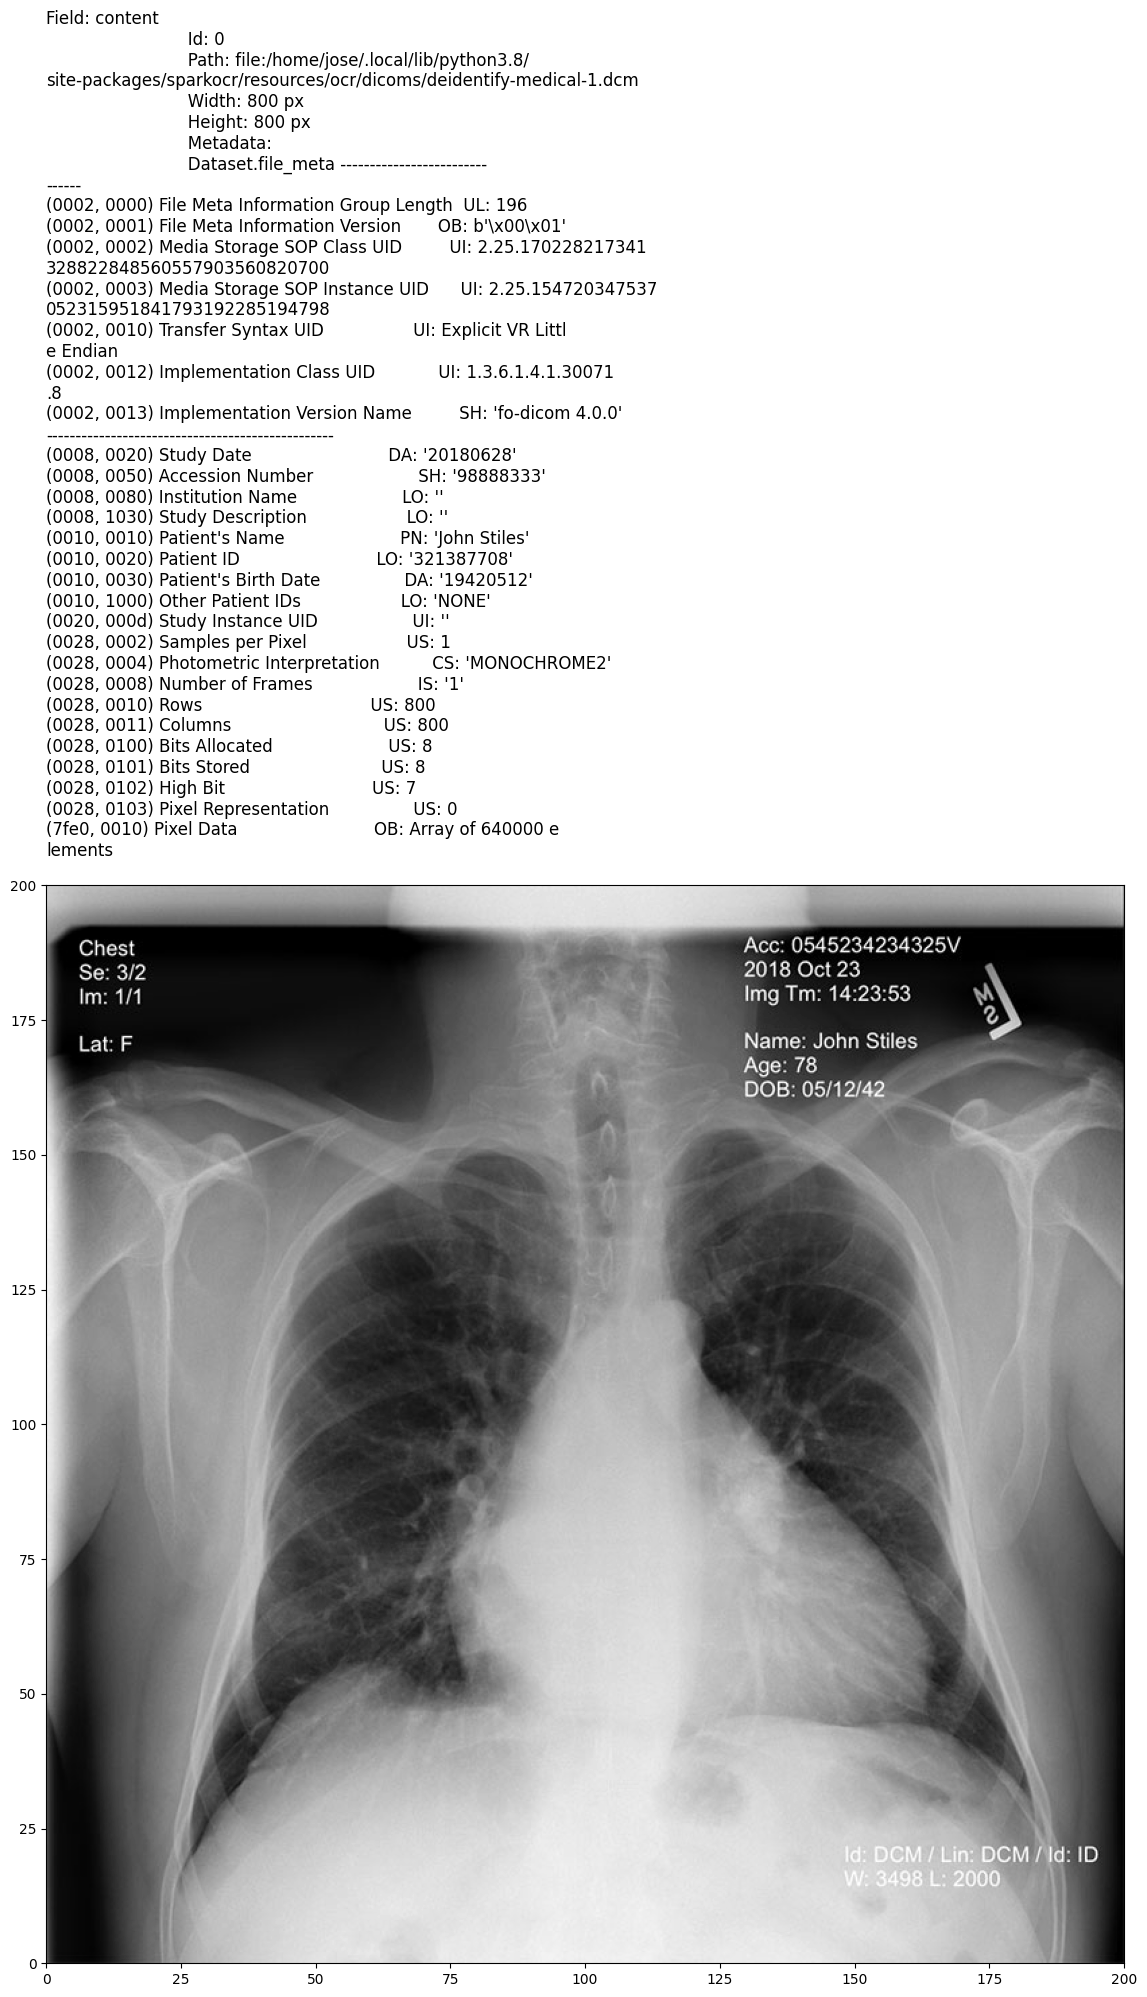

In [19]:
display_dicom(dicom_df, "content")

## Let's read the metadata into a Spark Dataframe
'metadata' column will contain it as a string

In [14]:
result = dicom.transform(dicom_df).cache()
print(result.select("metadata").collect()[0].metadata)

{
    "StudyDate": "20180628",
    "AccessionNumber": "98888333",
    "InstitutionName": "",
    "StudyDescription": "",
    "Patient'sName": "John Stiles",
    "PatientID": "321387708",
    "Patient'sBirthDate": "19420512",
    "OtherPatientIDs": "NONE",
    "StudyInstanceUID": "",
    "SamplesperPixel": "1",
    "PhotometricInterpretation": "MONOCHROME2",
    "NumberofFrames": "1",
    "Rows": "800",
    "Columns": "800",
    "BitsAllocated": "8",
    "BitsStored": "8",
    "HighBit": "7",
    "PixelRepresentation": "0"
}


## Pretrained Pipeline #1: `dicom_deid_generic_augmented_minimal`
This pipeline will attempt to remove the least possible amount of tags and image texts.

In [5]:
from sparkocr.pretrained import PretrainedPipeline
pipeline = PretrainedPipeline("dicom_deid_generic_augmented_minimal", 'en', 'clinical/ocr')

dicom_deid_generic_augmented_minimal download started this may take some time.
Approx size to download 1.7 GB
[OK!]


In [6]:
result = pipeline.transform(dicom_df).cache()

/home/jose/.local/lib/python3.8/site-packages/pyspark/sql/dataframe.py:169: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


/home/jose/.local/lib/python3.8/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR UI: 'anonymous'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warnings.warn(msg)


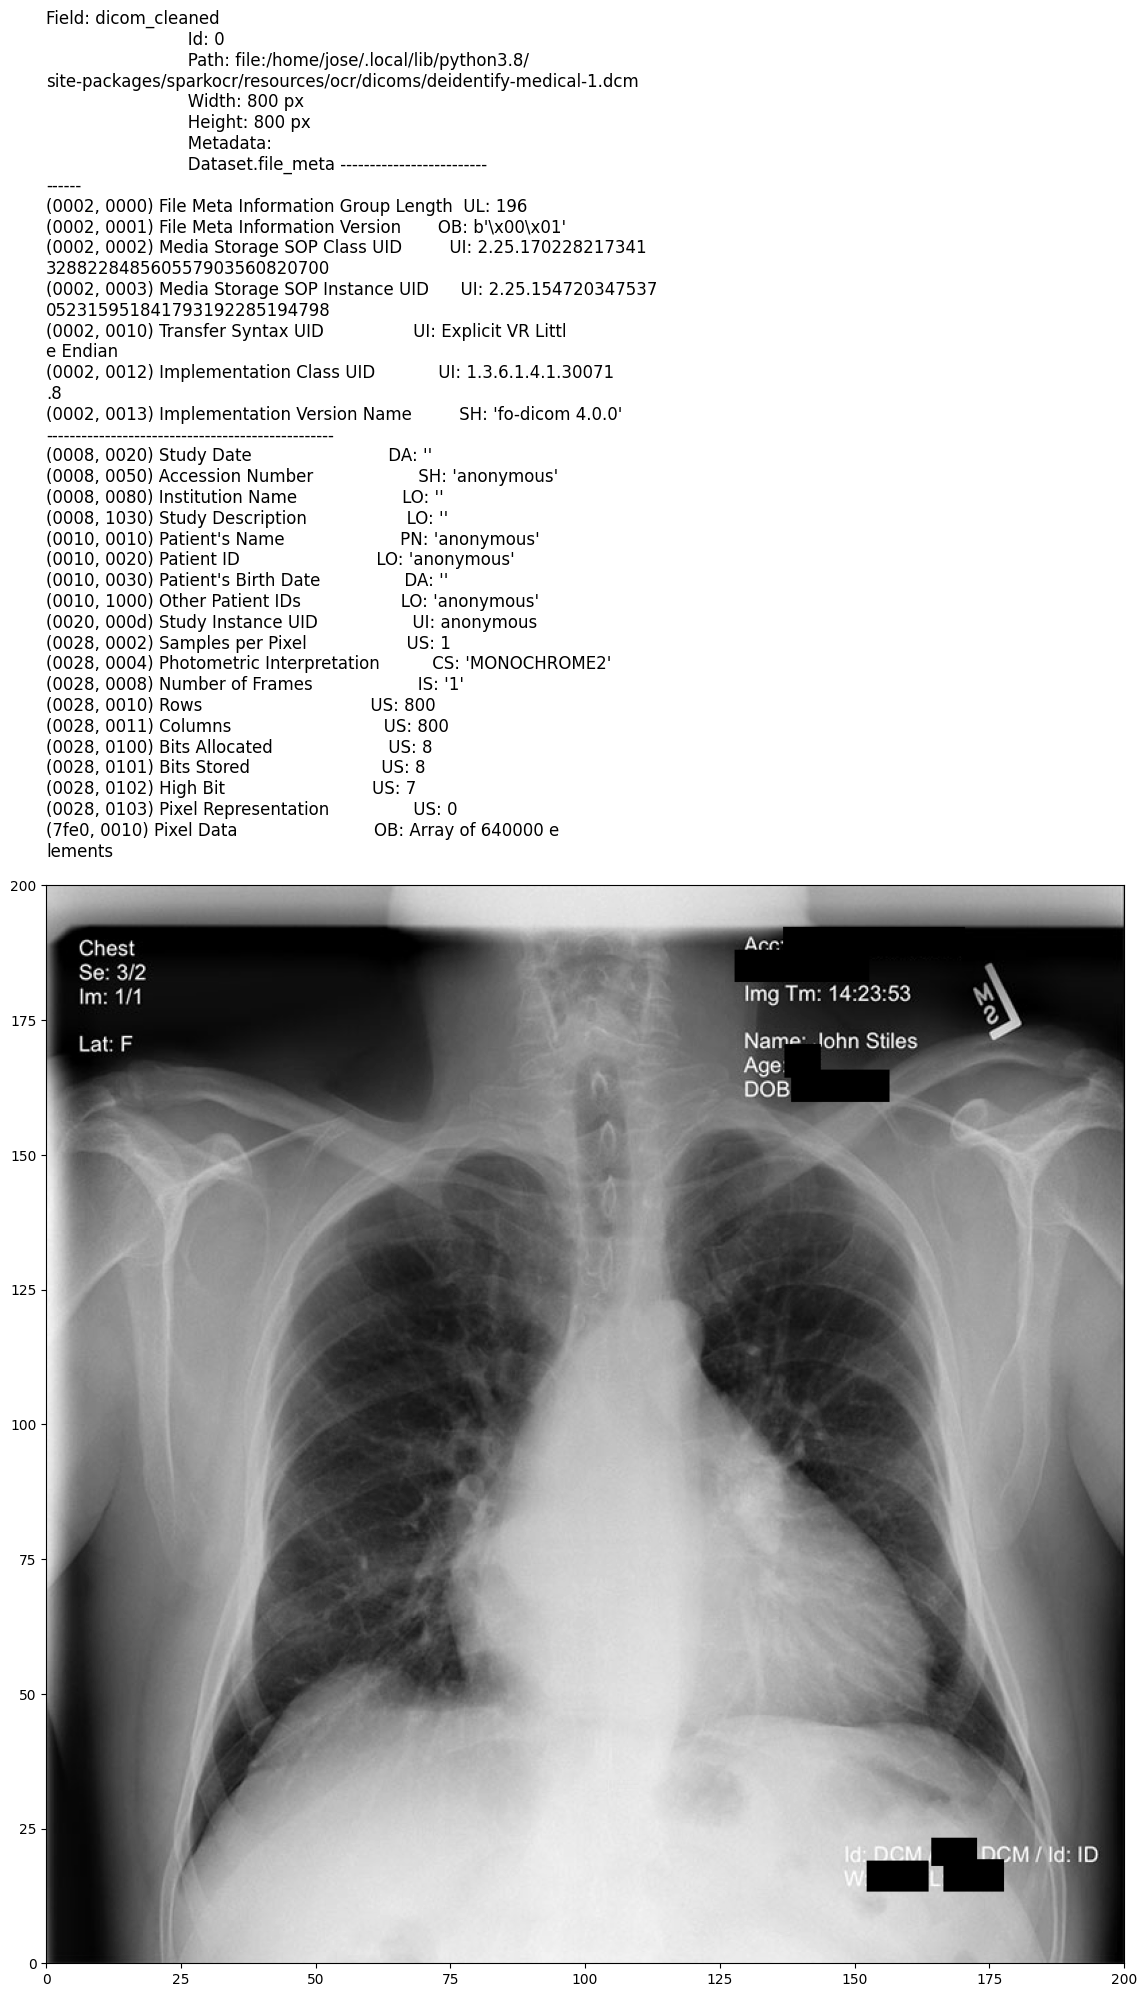

In [7]:
display_dicom(result, "dicom_cleaned")

## Pretrained Pipeline #2: `dicom_deid_full_anonymization`
This is the most aggressive version of the pipeline in which all texts in the images are removed together with most of the tags in the metadata.

In [12]:
pipeline = PretrainedPipeline("dicom_deid_full_anonymization", 'en', 'clinical/ocr')
result = pipeline.transform(dicom_df).cache()

dicom_deid_full_anonymization download started this may take some time.
Approx size to download 75.3 MB
[OK!]


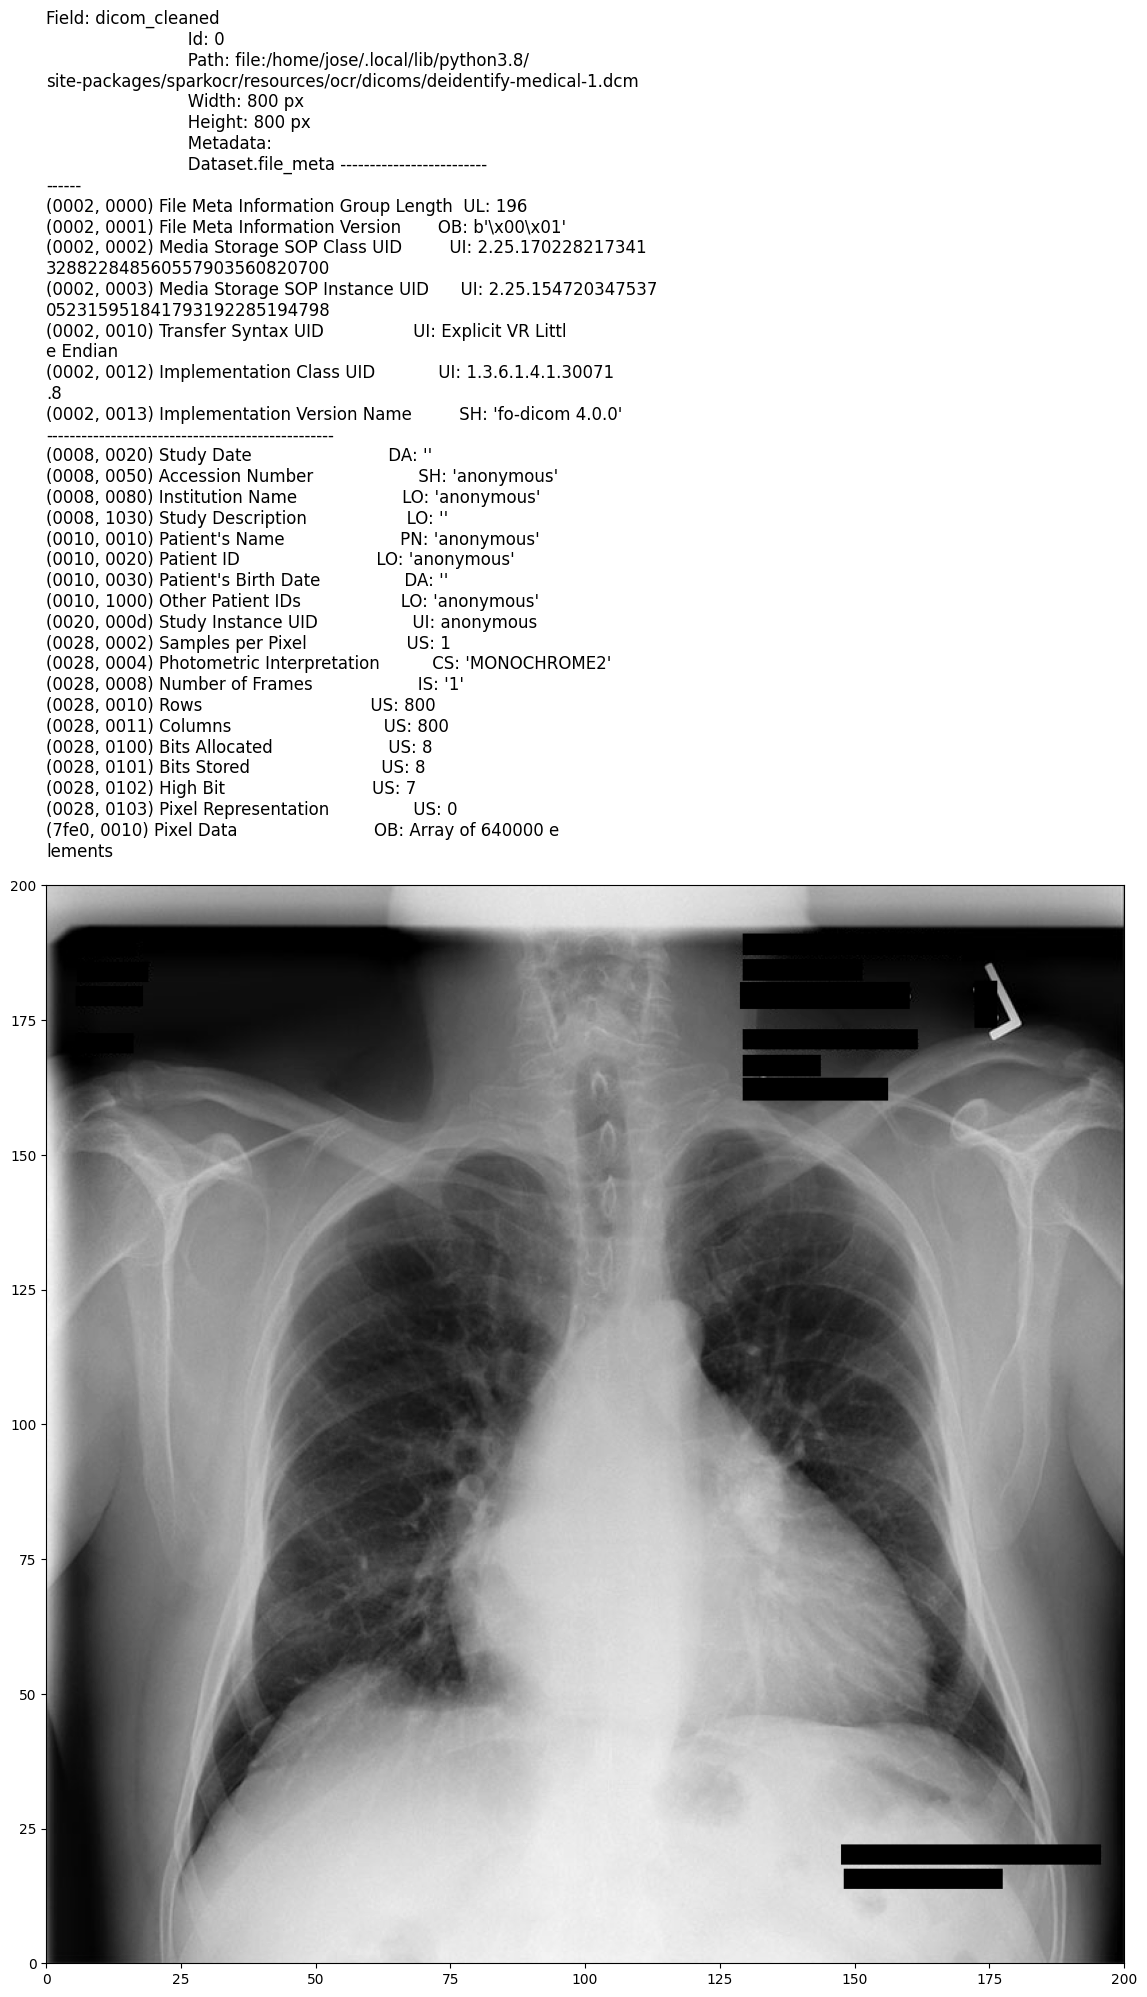

In [23]:
display_dicom(result, "dicom_cleaned")

## Pretrained Pipeline #3: `dicom_deid_generic_augmented_pseudonym`
This pipeline will attempt to replaces values in metadata with pseudonyms. Images will be de-identified for PHI.

In [13]:
pipeline = PretrainedPipeline("dicom_deid_generic_augmented_pseudonym", 'en', 'clinical/ocr')

dicom_deid_generic_augmented_pseudonym download started this may take some time.
Approx size to download 1.7 GB
[OK!]


/home/jose/.local/lib/python3.8/site-packages/pyspark/sql/dataframe.py:169: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(


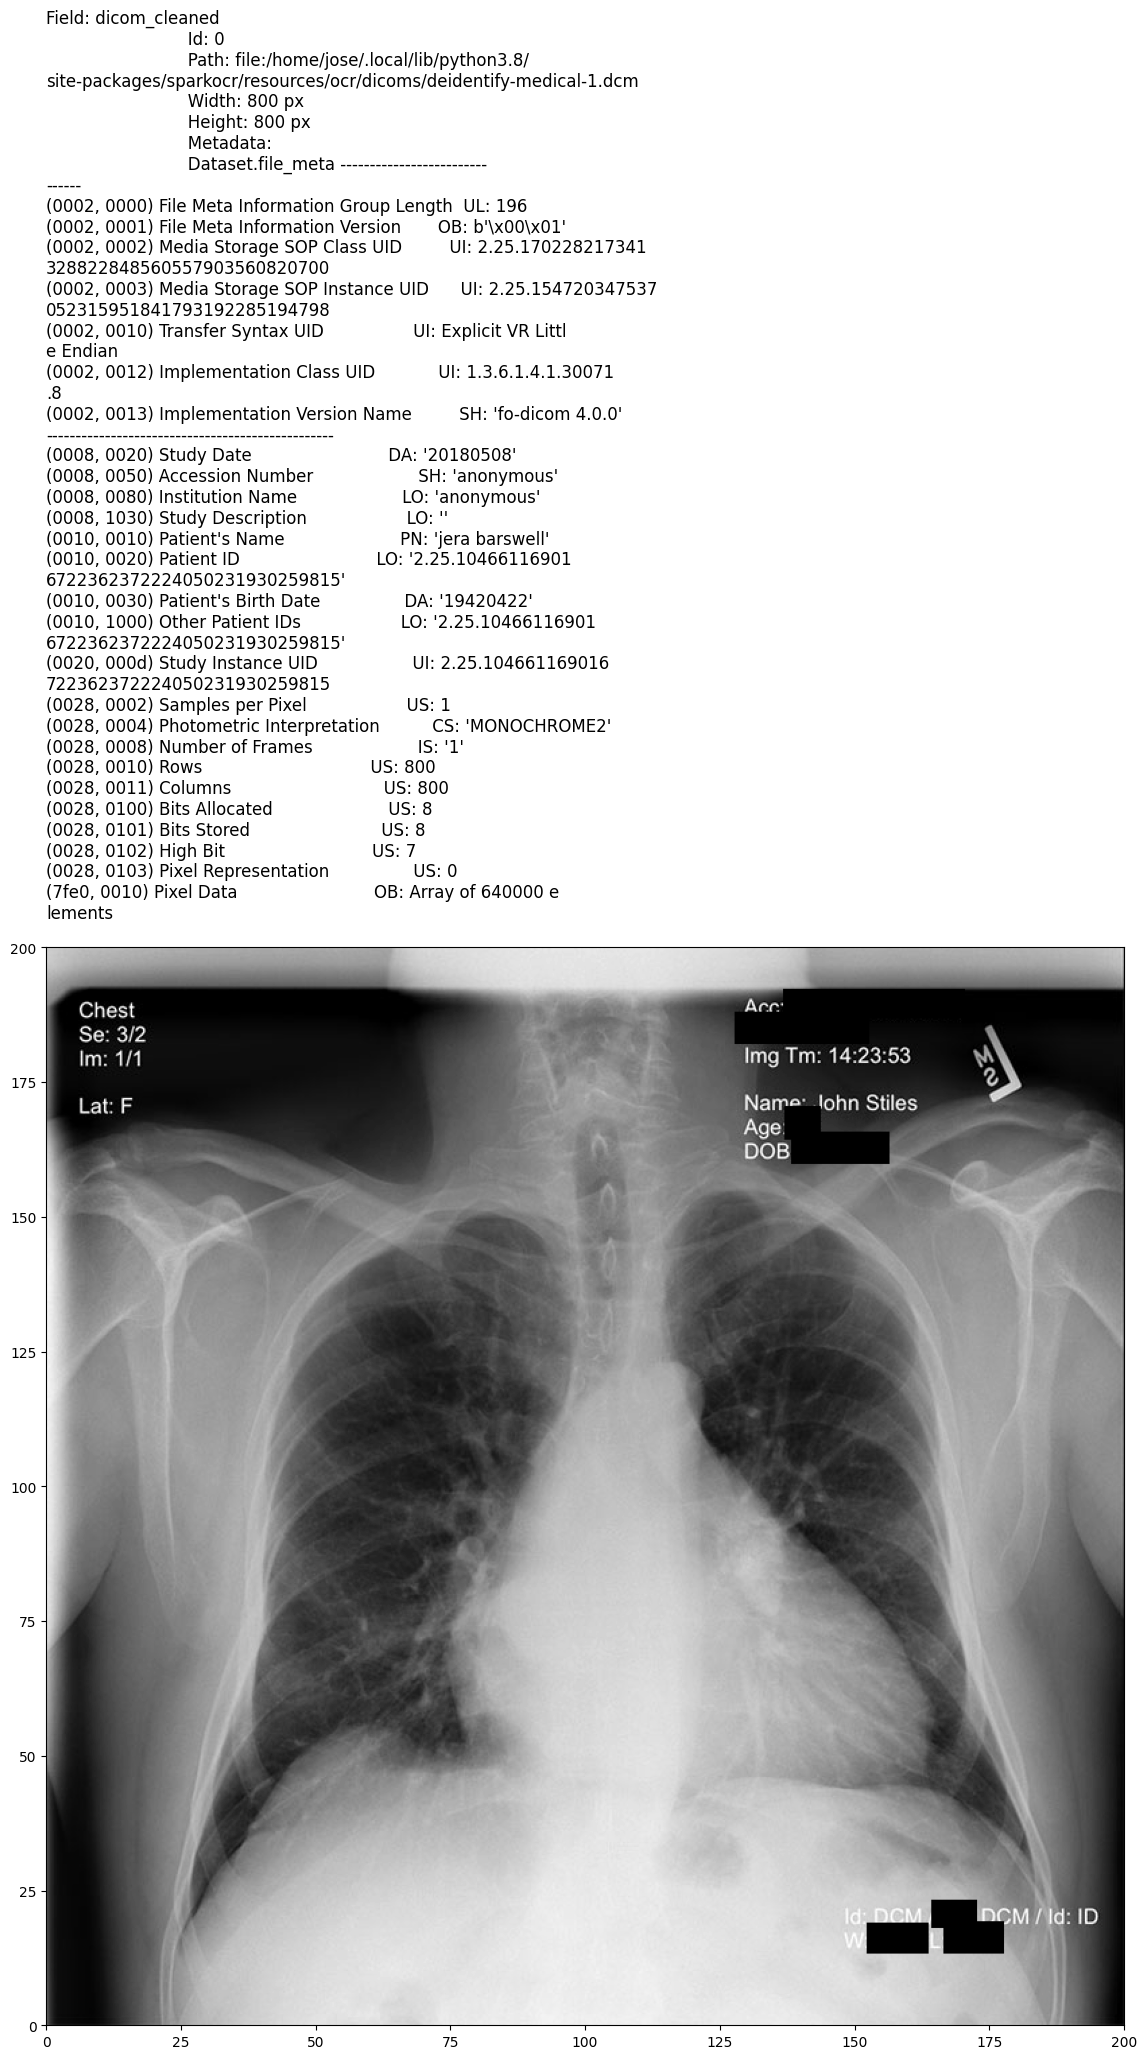

In [8]:
result = pipeline.transform(dicom_df).cache()
display_dicom(result, "dicom_cleaned")